## Data Preparation​


In [1]:
#Importing libraries used
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Reding the CSV file
compas_dataset=pd.read_csv('compas-scores-raw.csv')
compas_dataset.head()

,Person_ID,AssessmentID,Case_ID,Agency_Text,LastName,FirstName,MiddleName,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,...,RecSupervisionLevel,RecSupervisionLevelText,Scale_ID,DisplayText,RawScore,DecileScore,ScoreText,AssessmentType,IsCompleted,IsDeleted
0,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,7,Risk of Violence,-2.08,4,Low,New,1,0
1,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,8,Risk of Recidivism,-1.06,2,Low,New,1,0
2,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,18,Risk of Failure to Appear,15.00,1,Low,New,1,0
3,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,7,Risk of Violence,-2.84,2,Low,New,1,0
4,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,8,Risk of Recidivism,-1.50,1,Low,New,1,0


In [3]:
#summary statistics of the dataset
compas_dataset.describe()

,Person_ID,AssessmentID,Case_ID,ScaleSet_ID,RecSupervisionLevel,Scale_ID,RawScore,DecileScore,IsCompleted,IsDeleted
count,60843.000000,60843.000000,60843.000000,60843.000000,60843.000000,60843.000000,60843.000000,60843.000000,60843.0,60843.0
mean,53683.206154,68061.029190,60209.128149,21.819536,1.630048,11.000000,5.081457,3.571701,1.0,0.0
std,14363.648515,7320.208226,9638.501654,0.932614,0.944220,4.966596,10.080518,2.617854,0.0,0.0
min,656.000000,649.000000,350.000000,17.000000,1.000000,7.000000,-4.790000,-1.000000,1.0,0.0
25%,52039.000000,62582.000000,56021.000000,22.000000,1.000000,7.000000,-2.090000,1.000000,1.0,0.0
50%,57321.000000,68229.000000,61261.000000,22.000000,1.000000,8.000000,-0.710000,3.000000,1.0,0.0
75%,62748.000000,73870.000000,66554.000000,22.000000,2.000000,18.000000,14.000000,5.000000,1.0,0.0
max,68608.000000,79678.000000,72045.000000,22.000000,4.000000,18.000000,51.000000,10.000000,1.0,0.0


In [4]:
#structure of the dataset
compas_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60843 entries, 0 to 60842
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person_ID                60843 non-null  int64  
 1   AssessmentID             60843 non-null  int64  
 2   Case_ID                  60843 non-null  int64  
 3   Agency_Text              60843 non-null  object 
 4   LastName                 60843 non-null  object 
 5   FirstName                60843 non-null  object 
 6   MiddleName               15624 non-null  object 
 7   Sex_Code_Text            60843 non-null  object 
 8   Ethnic_Code_Text         60843 non-null  object 
 9   DateOfBirth              60843 non-null  object 
 10  ScaleSet_ID              60843 non-null  int64  
 11  ScaleSet                 60843 non-null  object 
 12  AssessmentReason         60843 non-null  object 
 13  Language                 60843 non-null  object 
 14  LegalStatus           

In [5]:
#checking if any column has null values
compas_dataset.isnull().sum()

,0
Person_ID,0
AssessmentID,0
Case_ID,0
Agency_Text,0
LastName,0
FirstName,0
MiddleName,45219
Sex_Code_Text,0
Ethnic_Code_Text,0
DateOfBirth,0


In [6]:
#dropping duplicate data
compas_dataset = compas_dataset.drop_duplicates()
compas_dataset

,Person_ID,AssessmentID,Case_ID,Agency_Text,LastName,FirstName,MiddleName,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,...,RecSupervisionLevel,RecSupervisionLevelText,Scale_ID,DisplayText,RawScore,DecileScore,ScoreText,AssessmentType,IsCompleted,IsDeleted
0,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,7,Risk of Violence,-2.08,4,Low,New,1,0
1,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,8,Risk of Recidivism,-1.06,2,Low,New,1,0
2,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,18,Risk of Failure to Appear,15.00,1,Low,New,1,0
3,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,7,Risk of Violence,-2.84,2,Low,New,1,0
4,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,8,Risk of Recidivism,-1.50,1,Low,New,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60838,65667,79665,72038,Probation,West,James,NaN,Male,African-American,06/21/64,...,3,Medium with Override Consideration,8,Risk of Recidivism,0.16,8,High,New,1,0
60839,65667,79665,72038,Probation,West,James,NaN,Male,African-American,06/21/64,...,3,Medium with Override Consideration,18,Risk of Failure to Appear,35.00,10,High,New,1,0
60840,68603,79669,72042,PRETRIAL,Ryan,Michael,NaN,Male,Caucasian,02/06/85,...,1,Low,7,Risk of Violence,-2.75,2,Low,New,1,0
60841,68603,79669,72042,PRETRIAL,Ryan,Michael,NaN,Male,Caucasian,02/06/85,...,1,Low,8,Risk of Recidivism,-0.34,5,Medium,New,1,0


In [7]:
#checking different values and their count for the column Scaleset to see if it has anything that need to be removed
compas_dataset["ScaleSet"].value_counts()

,count
ScaleSet,
Risk and Prescreen,58647
All Scales,2196


## Feature Engineering​

In [8]:
compas_dataset

,Person_ID,AssessmentID,Case_ID,Agency_Text,LastName,FirstName,MiddleName,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,...,RecSupervisionLevel,RecSupervisionLevelText,Scale_ID,DisplayText,RawScore,DecileScore,ScoreText,AssessmentType,IsCompleted,IsDeleted
0,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,7,Risk of Violence,-2.08,4,Low,New,1,0
1,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,8,Risk of Recidivism,-1.06,2,Low,New,1,0
2,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,18,Risk of Failure to Appear,15.00,1,Low,New,1,0
3,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,7,Risk of Violence,-2.84,2,Low,New,1,0
4,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,8,Risk of Recidivism,-1.50,1,Low,New,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60838,65667,79665,72038,Probation,West,James,NaN,Male,African-American,06/21/64,...,3,Medium with Override Consideration,8,Risk of Recidivism,0.16,8,High,New,1,0
60839,65667,79665,72038,Probation,West,James,NaN,Male,African-American,06/21/64,...,3,Medium with Override Consideration,18,Risk of Failure to Appear,35.00,10,High,New,1,0
60840,68603,79669,72042,PRETRIAL,Ryan,Michael,NaN,Male,Caucasian,02/06/85,...,1,Low,7,Risk of Violence,-2.75,2,Low,New,1,0
60841,68603,79669,72042,PRETRIAL,Ryan,Michael,NaN,Male,Caucasian,02/06/85,...,1,Low,8,Risk of Recidivism,-0.34,5,Medium,New,1,0


In [9]:
#removing all the columns which doesn't have impact on the output we are looking for
compas_dataset = compas_dataset.drop(columns=["Person_ID","DisplayText","AssessmentReason","RawScore","RecSupervisionLevel",'ScaleSet',"Case_ID","ScaleSet_ID","ScoreText","Agency_Text","Scale_ID","AssessmentType","RecSupervisionLevelText","AssessmentID","LastName","FirstName","MiddleName","IsDeleted","IsCompleted"], errors="ignore")
compas_dataset

,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,Language,LegalStatus,CustodyStatus,MaritalStatus,Screening_Date,DecileScore
0,Male,Caucasian,12/05/92,English,Pretrial,Jail Inmate,Single,1/1/13 0:00,4
1,Male,Caucasian,12/05/92,English,Pretrial,Jail Inmate,Single,1/1/13 0:00,2
2,Male,Caucasian,12/05/92,English,Pretrial,Jail Inmate,Single,1/1/13 0:00,1
3,Male,Caucasian,09/16/84,English,Pretrial,Jail Inmate,Married,1/1/13 0:00,2
4,Male,Caucasian,09/16/84,English,Pretrial,Jail Inmate,Married,1/1/13 0:00,1
...,...,...,...,...,...,...,...,...,...
60838,Male,African-American,06/21/64,English,Pretrial,Jail Inmate,Single,12/31/14 0:00,8
60839,Male,African-American,06/21/64,English,Pretrial,Jail Inmate,Single,12/31/14 0:00,10
60840,Male,Caucasian,02/06/85,English,Pretrial,Jail Inmate,Single,12/31/14 0:00,2
60841,Male,Caucasian,02/06/85,English,Pretrial,Jail Inmate,Single,12/31/14 0:00,5


In [10]:
#converting date fields into the default date format
compas_dataset["DateOfBirth"] = pd.to_datetime(compas_dataset["DateOfBirth"])
compas_dataset["Screening_Date"] = pd.to_datetime(compas_dataset["Screening_Date"])
compas_dataset[["DateOfBirth","Screening_Date"]].head(10)

/tmp/ipykernel_32642/3911915578.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  compas_dataset["DateOfBirth"] = pd.to_datetime(compas_dataset["DateOfBirth"])
/tmp/ipykernel_32642/3911915578.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  compas_dataset["Screening_Date"] = pd.to_datetime(compas_dataset["Screening_Date"])


,DateOfBirth,Screening_Date
0,1992-12-05,2013-01-01
1,1992-12-05,2013-01-01
2,1992-12-05,2013-01-01
3,1984-09-16,2013-01-01
4,1984-09-16,2013-01-01
5,1984-09-16,2013-01-01
6,1994-08-25,2013-01-01
7,1994-08-25,2013-01-01
8,1994-08-25,2013-01-01
9,1994-10-09,2013-01-01


In [11]:
#as the last one couldn't handle the different date format we are using this
compas_dataset["DateOfBirth"] = pd.to_datetime(compas_dataset["DateOfBirth"], errors="coerce", dayfirst=True)
compas_dataset["Screening_Date"] = pd.to_datetime(compas_dataset["Screening_Date"], errors="coerce", dayfirst=True)

In [12]:
#78 was interpreted as 2078 instead of 1978, manual correction was applied to ensure the dates were properly formatted
compas_dataset.loc[compas_dataset["DateOfBirth"].dt.year > compas_dataset["Screening_Date"].dt.year, "DateOfBirth"] -= pd.DateOffset(years=100)

In [13]:
#Calculated Age when the person commited the crime by using screening date column
compas_dataset["Age"] = (compas_dataset["Screening_Date"] - compas_dataset["DateOfBirth"]).dt.days // 365
compas_dataset["Age"]

,Age
0,20
1,20
2,20
3,28
4,28
...,...
60838,50
60839,50
60840,29
60841,29


In [14]:
#removed the date columns as it won't be of any use as we already have calculated age from it.
compas_dataset=compas_dataset.drop(columns=["DateOfBirth","Screening_Date"], errors="ignore")
compas_dataset = compas_dataset.dropna()
compas_dataset.head()


,Sex_Code_Text,Ethnic_Code_Text,Language,LegalStatus,CustodyStatus,MaritalStatus,DecileScore,Age
0,Male,Caucasian,English,Pretrial,Jail Inmate,Single,4,20
1,Male,Caucasian,English,Pretrial,Jail Inmate,Single,2,20
2,Male,Caucasian,English,Pretrial,Jail Inmate,Single,1,20
3,Male,Caucasian,English,Pretrial,Jail Inmate,Married,2,28
4,Male,Caucasian,English,Pretrial,Jail Inmate,Married,1,28


In [15]:
#To check different values and the count for sex in the dataset
compas_dataset["Sex_Code_Text"].value_counts()

,count
Sex_Code_Text,
Male,47514
Female,13329


In [16]:
#To check the ethnicity of the defendants in the dataset
compas_dataset["Ethnic_Code_Text"].value_counts()


,count
Ethnic_Code_Text,
African-American,27018
Caucasian,21783
Hispanic,8742
Other,2592
Asian,324
Native American,219
Arabic,75
African-Am,51
Oriental,39


In [17]:
from sklearn.preprocessing import LabelEncoder

le_ethnicity = LabelEncoder()
compas_dataset["Ethnic_Code_Text"] = le_ethnicity.fit_transform(compas_dataset["Ethnic_Code_Text"])

le_sex = LabelEncoder()
compas_dataset["Sex_Code_Text"] = le_sex.fit_transform(compas_dataset["Sex_Code_Text"])


In [18]:
compas_dataset.head()

,Sex_Code_Text,Ethnic_Code_Text,Language,LegalStatus,CustodyStatus,MaritalStatus,DecileScore,Age
0,1,4,English,Pretrial,Jail Inmate,Single,4,20
1,1,4,English,Pretrial,Jail Inmate,Single,2,20
2,1,4,English,Pretrial,Jail Inmate,Single,1,20
3,1,4,English,Pretrial,Jail Inmate,Married,2,28
4,1,4,English,Pretrial,Jail Inmate,Married,1,28


In [19]:
#Removing rows where the values is missing
compas_dataset = compas_dataset.dropna(subset=["DecileScore"])

## Model Training​

In [20]:
compas_dataset["target"] = (compas_dataset["DecileScore"] >= 5).astype(int)

compas_dataset["target"]

,target
0,0
1,0
2,0
3,0
4,0
...,...
60838,1
60839,1
60840,0
60841,1


In [21]:
#divided the dataset into independant and dependant features where X is independant and y is dependant feature
X = compas_dataset.drop(columns=["DecileScore","Sex_Code_Text","Ethnic_Code_Text","target"])
y = compas_dataset["target"]
X,y

(      Language LegalStatus CustodyStatus MaritalStatus  Age
 0      English    Pretrial   Jail Inmate        Single   20
 1      English    Pretrial   Jail Inmate        Single   20
 2      English    Pretrial   Jail Inmate        Single   20
 3      English    Pretrial   Jail Inmate       Married   28
 4      English    Pretrial   Jail Inmate       Married   28
 ...        ...         ...           ...           ...  ...
 60838  English    Pretrial   Jail Inmate        Single   50
 60839  English    Pretrial   Jail Inmate        Single   50
 60840  English    Pretrial   Jail Inmate        Single   29
 60841  English    Pretrial   Jail Inmate        Single   29
 60842  English    Pretrial   Jail Inmate        Single   29
 
 [60843 rows x 5 columns],
 0        0
 1        0
 2        0
 3        0
 4        0
         ..
 60838    1
 60839    1
 60840    0
 60841    1
 60842    0
 Name: target, Length: 60843, dtype: int64)

In [22]:
X = pd.get_dummies(X)
X = X.astype(int)

In [23]:
#Dividing the data into train and test where train dataset is used to train the model and test is used to evaluate the model
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
#Training the random forest model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

## Prediction Generation​

In [25]:
y_pred = rf_model.predict(X_test)

In [26]:
#To show the accuracy, precision and all the classification report
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6986605308570959
              precision    recall  f1-score   support

           0       0.71      0.93      0.81      8301
           1       0.58      0.20      0.30      3868

    accuracy                           0.70     12169
   macro avg       0.64      0.57      0.55     12169
weighted avg       0.67      0.70      0.65     12169



In [27]:
#showing the importance of features used in the model
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

Age                                  0.575612
MaritalStatus_Single                 0.165567
MaritalStatus_Married                0.102910
MaritalStatus_Divorced               0.028091
CustodyStatus_Probation              0.022690
LegalStatus_Pretrial                 0.019800
LegalStatus_Other                    0.018233
LegalStatus_Post Sentence            0.010244
CustodyStatus_Jail Inmate            0.009182
CustodyStatus_Pretrial Defendant     0.008287
MaritalStatus_Separated              0.007519
MaritalStatus_Significant Other      0.006670
Language_English                     0.005408
LegalStatus_Probation Violator       0.004869
Language_Spanish                     0.004430
LegalStatus_Conditional Release      0.003274
MaritalStatus_Widowed                0.002140
MaritalStatus_Unknown                0.001693
CustodyStatus_Residential Program    0.001230
CustodyStatus_Parole                 0.000909
LegalStatus_Deferred Sentencing      0.000497
LegalStatus_Parole Violator       

In [28]:
protected = compas_dataset[["Ethnic_Code_Text", "Sex_Code_Text"]]

In [29]:
compas_dataset

,Sex_Code_Text,Ethnic_Code_Text,Language,LegalStatus,CustodyStatus,MaritalStatus,DecileScore,Age,target
0,1,4,English,Pretrial,Jail Inmate,Single,4,20,0
1,1,4,English,Pretrial,Jail Inmate,Single,2,20,0
2,1,4,English,Pretrial,Jail Inmate,Single,1,20,0
3,1,4,English,Pretrial,Jail Inmate,Married,2,28,0
4,1,4,English,Pretrial,Jail Inmate,Married,1,28,0
...,...,...,...,...,...,...,...,...,...
60838,1,1,English,Pretrial,Jail Inmate,Single,8,50,1
60839,1,1,English,Pretrial,Jail Inmate,Single,10,50,1
60840,1,4,English,Pretrial,Jail Inmate,Single,2,29,0
60841,1,4,English,Pretrial,Jail Inmate,Single,5,29,1


In [33]:
compas_dataset["prediction"] = rf_model.predict(X)
compas_dataset["prediction"]

,prediction
0,1
1,1
2,1
3,0
4,0
...,...
60838,0
60839,0
60840,0
60841,0


## Bias Detection and Bias Gap Calculation​

In [38]:
compas_dataset["Ethnicity_Label"] = le_ethnicity.inverse_transform(compas_dataset["Ethnic_Code_Text"])

In [47]:
compas_dataset["Ethnicity_Label"] = compas_dataset["Ethnicity_Label"].replace({
    "African-Am": "African-American"
})

In [48]:
rates_ethnicity = compas_dataset.groupby("Ethnicity_Label")["prediction"].mean()
print(rates_ethnicity)

Ethnicity_Label
African-American    0.157708
Arabic              0.080000
Asian               0.055556
Caucasian           0.078088
Hispanic            0.084077
Native American     0.109589
Oriental            0.076923
Other               0.094907
Name: prediction, dtype: float64


In [49]:
di = rates_ethnicity.min() / rates_ethnicity.max()
print("Disparate Impact:", di)

Disparate Impact: 0.3522682907784805


In [50]:
if di < 0.8:
    print("⚠️ Bias Detected")
else:
    print("✅ No Significant Bias")

⚠️ Bias Detected


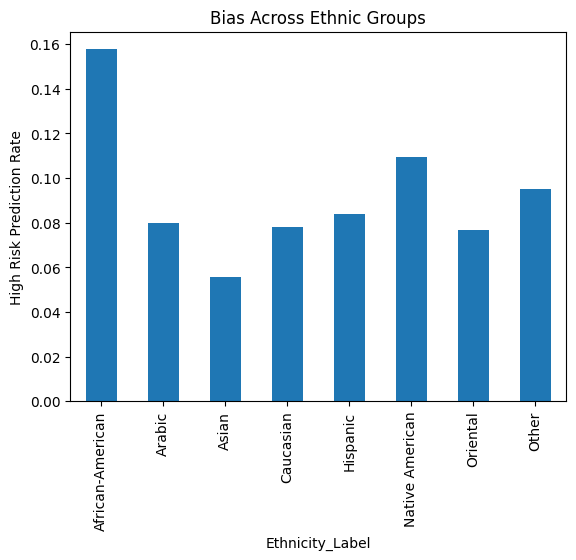

In [51]:
import matplotlib.pyplot as plt

rates_ethnicity.plot(kind="bar")
plt.title("Bias Across Ethnic Groups")
plt.ylabel("High Risk Prediction Rate")
plt.show()

/tmp/ipykernel_32642/2648275208.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


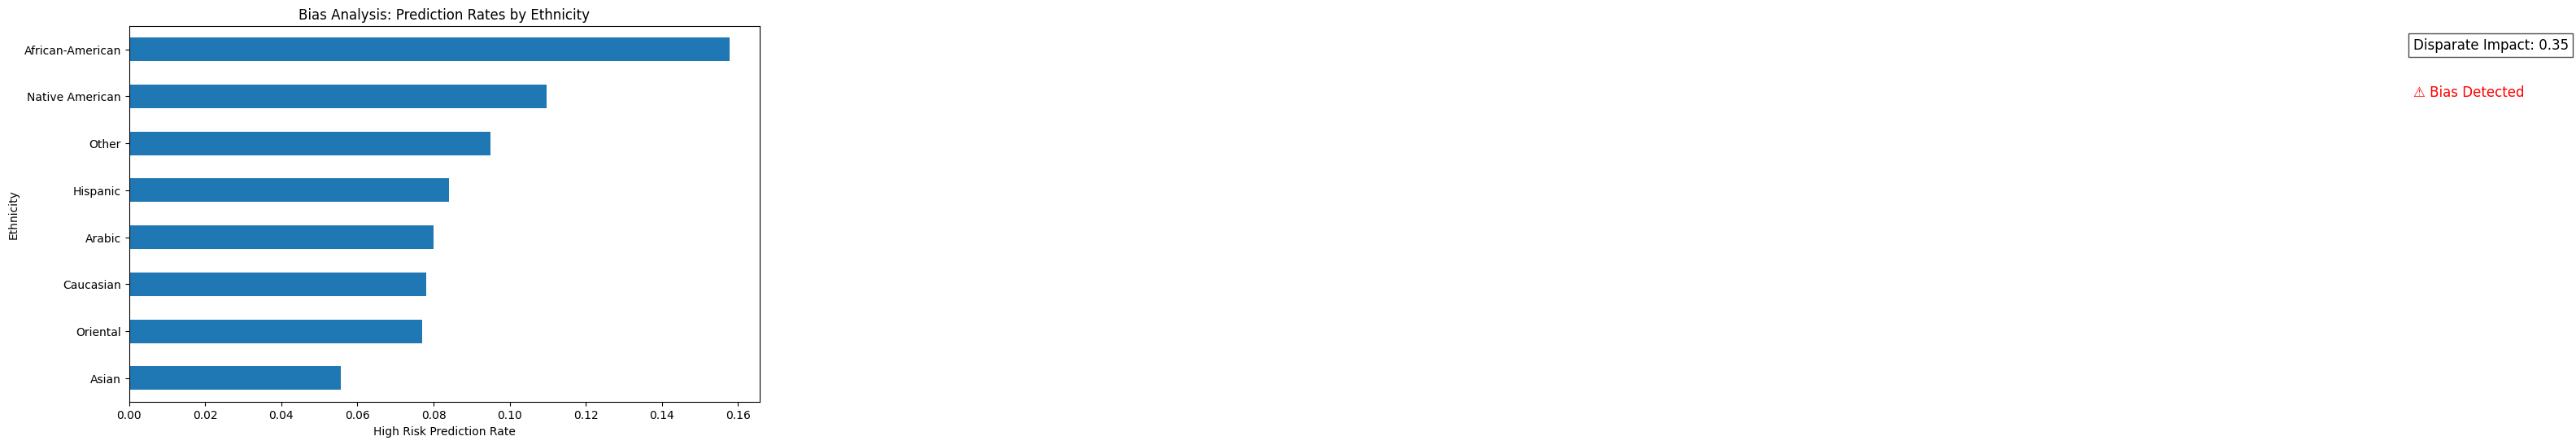

In [57]:
import matplotlib.pyplot as plt

# --- Step 1: Compute rates ---
rates_ethnicity = compas_dataset.groupby("Ethnicity_Label")["prediction"].mean()

# --- Step 2: Compute Disparate Impact ---
di = rates_ethnicity.min() / rates_ethnicity.max()

# --- Step 3: Create figure ---
plt.figure(figsize=(10,6))

# Bar chart
rates_ethnicity.sort_values().plot(kind="barh")

# Labels & title
plt.title("Bias Analysis: Prediction Rates by Ethnicity")
plt.xlabel("High Risk Prediction Rate")
plt.ylabel("Ethnicity")

# --- Step 4: Add DI text on plot ---
plt.text(
    0.6,  # x position (adjust if needed)
    len(rates_ethnicity)-1,
    f"Disparate Impact: {di:.2f}",
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.7)
)

# --- Step 5: Bias message ---
if di < 0.8:
    bias_msg = "⚠️ Bias Detected"
else:
    bias_msg = "✅ No Significant Bias"

plt.text(
    0.6,
    len(rates_ethnicity)-2,
    bias_msg,
    fontsize=12,
    color="red" if di < 0.8 else "green"
)

plt.tight_layout()
plt.show()